In [9]:
import pandas as pd
import os


PATH = "/scratch/am10150/projects/rtcloud-projects/mindeye/3t/derivatives/sub-005_ses-03_task-C_recons_byrepeats_rt/train_data_scaling-ses1-2_concat"
# PATH = "/scratch/am10150/projects/rtcloud-projects/mindeye/3t/derivatives/sub-005_ses-03_task-C_recons_byrepeats_rt/train_data_scaling-ses1-2_concat_unionmask"
folders = os.listdir(PATH)
metrics_dfs = []
for folder in folders:
    if os.path.isdir(os.path.join(PATH, folder)) is False:
        continue
    print(folder)
    data_size = int(folder.split("sample=")[1].split("_")[0])
    data_size = data_size * 10
    
    metrics = pd.read_csv(os.path.join(PATH, folder, "0", "metrics.csv"))
    metrics = metrics[metrics['category'] == 'rep']
    metrics['data_size'] = data_size
    metrics_dfs.append(metrics)
    

sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=6_avgrepeats_finalmask_epochs_150_delay=0
sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=8_avgrepeats_finalmask_epochs_150_delay=0
sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=9_avgrepeats_finalmask_epochs_150_delay=0
sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=3_avgrepeats_finalmask_epochs_150_delay=0
sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=5_avgrepeats_finalmask_epochs_150_delay=0
sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=10_avgrepeats_finalmask_epochs_150_delay=0
sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=2_avgrepeats_finalmask_epochs_150_delay=0
sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=7_avgrepeats_finalmask_epochs_150_delay=0
sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=1_avgrepeats_finalmask_epochs_150_delay=0
sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=4_avgrepeats_finalmask_epochs_150_delay=0


In [10]:
metrics_all = pd.concat(metrics_dfs)

In [11]:
METRICS = [
    'all_fwd_acc',
    'all_bwd_acc',
    'pixcorr',
    'ssim',
    'alexnet2',
    'alexnet5',
    'inception',
    'clip',
    'efficientnet',
    'swav',
]

METRICS2Names = {
    "all_fwd_acc": "Image Retrieval",
    "all_bwd_acc": "Brain Retrieval",
    "pixcorr": "PixCorr",
    "ssim": "SSIM",
    "alexnet2": "AlexNet(2)",
    "alexnet5": "AlexNet(5)",
    "inception": "InceptionV3",
    "clip": "CLIP",
    "efficientnet": "EffNet-B",
    "swav": "SwAV",
}

# METRICS = [METRICS2Names[met] for met in METRICS]

# metrics_all = metrics_all.rename(columns=METRICS2Names)
metrics_all.groupby("data_size")[METRICS].mean()
# metrics_all.groupby('data_size').mean()

,all_fwd_acc,all_bwd_acc,pixcorr,ssim,alexnet2,alexnet5,inception,clip,efficientnet,swav
data_size,,,,,,,,,,
10,0.253333,0.133333,0.044591,0.313243,0.671837,0.688435,0.587755,0.563265,0.957349,0.611257
20,0.313333,0.306667,0.074888,0.334486,0.724490,0.760136,0.637143,0.605850,0.942208,0.586098
30,0.426667,0.346667,0.092696,0.337525,0.769252,0.805986,0.653333,0.617007,0.917806,0.570412
40,0.480000,0.420000,0.087706,0.336995,0.756190,0.790748,0.671429,0.627755,0.916268,0.569332
50,0.486667,0.493333,0.084493,0.337696,0.750884,0.784490,0.646803,0.636190,0.908159,0.561788
60,0.546667,0.506667,0.098738,0.346319,0.752517,0.774150,0.655238,0.648027,0.910088,0.560357
70,0.540000,0.566667,0.087445,0.342055,0.771293,0.797415,0.665986,0.637143,0.916944,0.568924
80,0.573333,0.533333,0.099612,0.361504,0.754286,0.799456,0.712925,0.638503,0.918884,0.569845
90,0.566667,0.553333,0.095598,0.332224,0.777415,0.812245,0.726259,0.632245,0.917421,0.574643


<Figure size 1000x600 with 0 Axes>

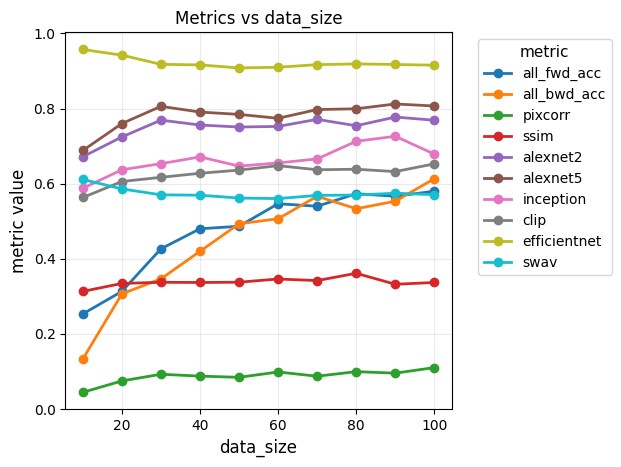

In [12]:
agg = metrics_all.groupby("data_size")[METRICS].mean()

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
agg.plot(marker='o', linewidth=2)
plt.xlabel('data_size')
plt.ylabel('metric value')
plt.title('Metrics vs data_size')
plt.grid(True)
plt.legend(title='metric', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

### Normalize metrics and invert efficient-net and swav

In [13]:
metric_maxs = {
}
agg_ri = agg.reset_index().copy()

# decreasing metrics
DESC_METRICS = ["efficientnet", "swav"]
for desc_met in DESC_METRICS:
    agg_ri[desc_met] = 1 - agg_ri[desc_met]

for metric in METRICS:
    metric_max = agg_ri[metric].max()
    agg_ri[metric] = agg_ri[metric].apply(lambda x: x / metric_max)


In [14]:
agg_ri

,data_size,all_fwd_acc,all_bwd_acc,pixcorr,ssim,alexnet2,alexnet5,inception,clip,efficientnet,swav
0,10,0.436782,0.217391,0.403904,0.866499,0.864193,0.847571,0.809292,0.862860,0.464400,0.884225
1,20,0.540230,0.500000,0.678332,0.925264,0.931922,0.935846,0.877295,0.928095,0.629265,0.941451
2,30,0.735632,0.565217,0.839634,0.933669,0.989499,0.992295,0.899588,0.945185,0.894962,0.977129
3,40,0.827586,0.684783,0.794438,0.932204,0.972699,0.973534,0.924504,0.961651,0.911713,0.979585
4,50,0.839080,0.804348,0.765333,0.934142,0.965873,0.965829,0.890596,0.974573,1.000000,0.996745
5,60,0.942529,0.826087,0.894370,0.957996,0.967973,0.953099,0.902211,0.992705,0.979005,1.000000
6,70,0.931034,0.923913,0.792072,0.946201,0.992125,0.981742,0.917010,0.976032,0.904353,0.980514
7,80,0.988506,0.869565,0.902286,1.000000,0.970249,0.984255,0.981641,0.978116,0.883227,0.978418
8,90,0.977011,0.902174,0.865920,0.919006,1.000000,1.000000,1.000000,0.968529,0.899156,0.967505
9,100,1.000000,1.000000,1.000000,0.932164,0.989149,0.993467,0.934620,1.000000,0.920206,0.976064


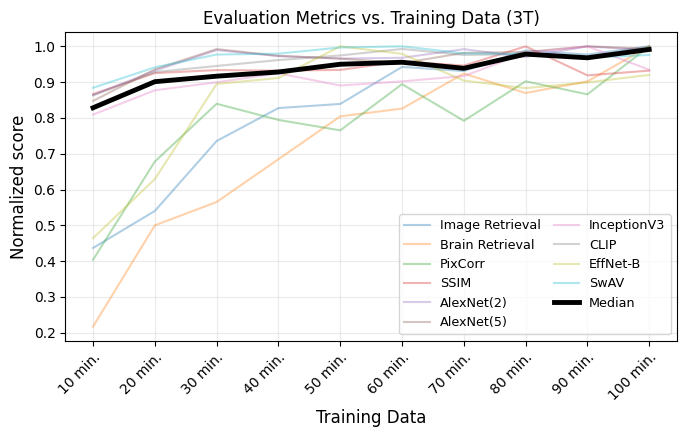

In [15]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np

# --- Global style to match the image ---
mpl.rcParams.update({
    "font.family": "sans-serif",      # <--- SWITCHED TO SANS-SERIF
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
})

# --- DEMO DATA GENERATION ---
np.random.seed(42)
x_vals = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
data = {"data_size": x_vals}
metric_names = ["all_fwd_acc", "all_bwd_acc", "pixcorr", "ssim", 
                "alexnet2", "alexnet5", "inception", "clip", "efficientnet", "swav"]

# --- CALCULATE MEAN ---
agg_ri["minutes"] = agg_ri["data_size"].astype(int).astype(str) + " min."
metric_cols = [c for c in agg_ri.columns if c not in ["data_size", "minutes"]]
agg_ri["Median"] = agg_ri[metric_cols].median(axis=1)

# Calculate the row-wise MEAN (across all metrics for each x-value)
# agg_ri["Mean"] = agg_ri[metric_cols].mean(axis=1)


# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(7, 4.5)) 

# 1. Plot the "Background" lines (Individual Metrics)
colors = plt.cm.tab10.colors 

for i, col in enumerate(metric_cols):
    ax.plot(
        agg_ri["minutes"],
        agg_ri[col],
        label=METRICS2Names.get(col, col),
        color=colors[i % len(colors)],
        linewidth=1.5,
        alpha=0.35,       # Faint background lines
        marker="",        
    )

# 2. Plot the "Highlight" line (The Mean)
ax.plot(
    agg_ri["minutes"],
    agg_ri["Median"],       # Using the Mean column
    label="Median",         # Updated label
    color="black",        
    linewidth=3.5,        
    markersize=5,
    zorder=10             
)

# --- CLEANING UP THE LOOK ---
# # 1. Remove Grid Lines
# ax.grid(False) 

# 2. Remove Bottom Ticks (keep labels)
# ax.tick_params(axis="x", bottom=False)  # <--- Removes the little black lines

# Labels & Title
ax.set_title("Evaluation Metrics vs. Training Data (3T)")
ax.set_xlabel("Training Data")
ax.set_ylabel("Normalized score")

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Legend
ax.legend(
    frameon=True,
    loc="lower right",
    ncol=2,             # <--- Key change to make it short and wide
    fontsize="small",   # <--- Key change to save space
    columnspacing=1.0   # Adjust gap between columns
)

# Layout
plt.tight_layout()

# --- Export ---
plt.savefig("training_data_eval_metrics_ses1mask.png", bbox_inches="tight")
plt.show()

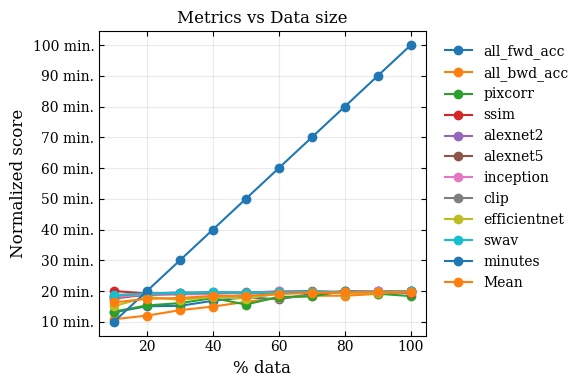

In [58]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Global style to match the image ---
mpl.rcParams.update({
    "font.family": "serif",           # Serif font (like Times or Computer Modern)
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 1.5,           # Slightly thinner line to match image
    "lines.markersize": 6,
    "axes.grid": True,
    "grid.alpha": 0.25,               # Very faint grid
    "grid.linestyle": "-",            # Solid grid lines (not dashed)
    "xtick.direction": "in",          # Ticks point inside
    "ytick.direction": "in",          # Ticks point inside
    "xtick.top": True,                # Ticks visible on top axis
    "ytick.right": True,              # Ticks visible on right axis
})

# --- Figure ---
fig, ax = plt.subplots(figsize=(6, 4)) 

# Custom palette matching the image (Dark Blue, Bright Green)
# You can tweak these hex codes if needed
# custom_colors = ["#1f6199", "#2db85c"] 

# Assuming agg_ri is your DataFrame
for i, col in enumerate(agg_ri.columns):
    if col != "data_size":
        ax.plot(
            agg_ri["data_size"],
            agg_ri[col],
            label=col,
            # color=custom_colors[i % len(custom_colors)],
            marker="o",
        )

# --- DEMO DATA (Uncomment and replace with your loop above) ---
# import numpy as np
# x = [0, 1, 3, 5, 10, 15, 20, 63]
# y1 = [0.38, 0.49, 0.55, 0.72, 0.84, 0.87, 0.86, 0.91] # Blue line approx
# y2 = [0.08, 0.06, 0.24, 0.41, 0.38, 0.36, 0.42, 0.50] # Green line approx

# ax.plot(x, y1, label="Betas average (3 repeats)", color=custom_colors[0], marker="o")
# ax.plot(x, y2, label="Single trial (first repeat)", color=custom_colors[1], marker="o")
# -------------------------------------------------------------

# Labels & Title
ax.set_title("Metrics vs Data size")
ax.set_xlabel("% data")
ax.set_ylabel("Normalized score")

# Legend with Title
# The image has the legend in the bottom right, no frame, with a title
# ax.legend(
#     title="Betas type",
#     title_fontsize=10,
#     frameon=False,
#     loc="lower right",
# )
ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
)

# Ensure the 'box' look is preserved (Ticks are already set to True in rcParams)
# But we explicitly ensure spines are black/visible if previously hidden
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)

# Layout
fig.tight_layout()

# --- Export ---
# plt.savefig("results_plot_styled.pdf", bbox_inches="tight")
plt.show()

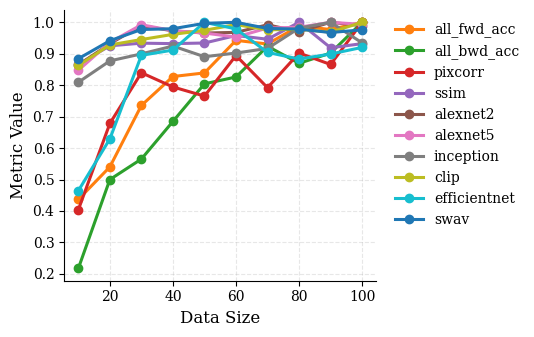

In [11]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Global style ---
mpl.rcParams.update({
    "font.family": "serif",          # or "sans-serif" if your paper uses that
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2.2,
    "lines.markersize": 6,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

# --- Figure ---
fig, ax = plt.subplots(figsize=(5.5, 3.5))  # good for single-column paper

# Colorblind-friendly palette
colors = plt.cm.tab10.colors

for i, col in enumerate(agg_ri.columns):
    if col != "data_size":
        ax.plot(
            agg_ri["data_size"],
            agg_ri[col],
            label=col,
            color=colors[i % len(colors)],
            marker="o",
        )

# Labels
ax.set_xlabel("Data Size")
ax.set_ylabel("Metric Value")

# Legend
ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
)

# Clean spines (modern paper look)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Layout
fig.tight_layout()

# --- Export as vector for paper ---
plt.savefig("results_plot.pdf", bbox_inches="tight")
plt.show()


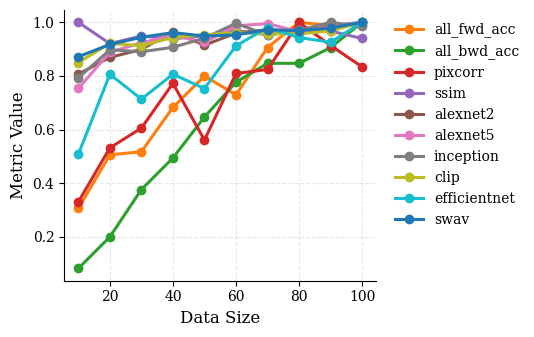

In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Global style ---
mpl.rcParams.update({
    "font.family": "serif",          # or "sans-serif" if your paper uses that
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2.2,
    "lines.markersize": 6,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

# --- Figure ---
fig, ax = plt.subplots(figsize=(5.5, 3.5))  # good for single-column paper

# Colorblind-friendly palette
colors = plt.cm.tab10.colors

for i, col in enumerate(agg_ri.columns):
    if col != "data_size":
        ax.plot(
            agg_ri["data_size"],
            agg_ri[col],
            label=col,
            color=colors[i % len(colors)],
            marker="o",
        )

# Labels
ax.set_xlabel("Data Size")
ax.set_ylabel("Metric Value")

# Legend
ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
)

# Clean spines (modern paper look)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Layout
fig.tight_layout()

# --- Export as vector for paper ---
plt.savefig("results_plot.pdf", bbox_inches="tight")
plt.show()


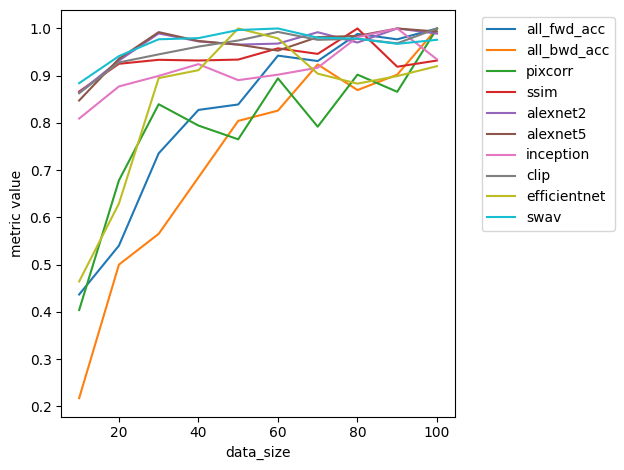

In [10]:
import matplotlib.pyplot as plt

plt.figure()
for col in agg_ri.columns:
    if col != "data_size":
        plt.plot(agg_ri["data_size"], agg_ri[col], label=col)

plt.xlabel("data_size")
plt.ylabel("metric value")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Lets plot recons of a certain repeat across all `data_size`

In [ ]:
import torch
from tqdm import tqdm

def process_per_datasample(path: str, rep_idx: int = 1, return_gt: bool = True):
    img_folders_path = os.path.join(path, '0/sanity_check_individual_reps')
    img_folders = os.listdir(img_folders_path)
    gts, recons = [], []
    for folder in img_folders:
        if return_gt:
            gt = torch.load(os.path.join(img_folders_path, folder, 'all_ground_truth.pt'))  # reps x 3 x h x w
            gt = gt[rep_idx, :]  # 3 x h x w
            gts.append(gt)

        recon = torch.load(os.path.join(img_folders_path, folder, 'all_recons.pt'))  # reps x 3 x h x w        
        recon = recon[rep_idx, :]  # 3 x h x w
        recons.append(recon)
    
    recons = torch.stack(recons)  # num_imgs x 3 x h x w
    if return_gt:
        gts = torch.stack(gts)
    
    if return_gt:
        return gts, recons
    else:
        return recons


folders = os.listdir(PATH)

metrics_dfs = []
data_scaling_recons = {}

for folder in tqdm(folders):
    if os.path.isdir(os.path.join(PATH, folder)) is False:
        continue
    print(folder)
    data_size = int(folder.split("sample=")[1].split("_")[0])
    data_size = data_size * 10
    
    if data_size == 10:
        gts, recons = process_per_datasample(
            path=os.path.join(PATH, folder),
            return_gt=True
        )
        data_scaling_recons['gt'] = gts
        data_scaling_recons[data_size] = recons
    else:
        recons = process_per_datasample(
            path=os.path.join(PATH, folder),
            return_gt=False
        )
        data_scaling_recons[data_size] = recons


  0%|                                                                                                                                             | 0/10 [00:00<?, ?it/s]

sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=7_avgrepeats_unionmask_epochs_150_delay=0


 10%|█████████████▎                                                                                                                       | 1/10 [00:01<00:16,  1.88s/it]

sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=6_avgrepeats_unionmask_epochs_150_delay=0


 20%|██████████████████████████▌                                                                                                          | 2/10 [00:03<00:15,  1.88s/it]

...

 80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████▍                          | 8/10 [00:16<00:03,  1.88s/it]

sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=10_avgrepeats_unionmask_epochs_150_delay=0


 90%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋             | 9/10 [00:17<00:01,  1.87s/it]

sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=4_avgrepeats_unionmask_epochs_150_delay=0


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:19<00:00,  1.98s/it]


In [ ]:
import torch
import matplotlib.pyplot as plt

# Sort reconstruction keys (10, 20, ..., 100)
recon_keys = sorted(k for k in data_scaling_recons.keys() if k != "gt")

num_images = data_scaling_recons["gt"].shape[0]
num_cols = 1 + len(recon_keys)  # GT + recon columns

def to_img(x):
    """CxHxW -> HxWxC for imshow"""
    if torch.is_tensor(x):
        x = x.detach().cpu()
    return x.permute(1, 2, 0).clamp(0, 1)

fig, axes = plt.subplots(
    num_images,
    num_cols,
    figsize=(2 * num_cols, 2 * num_images)
)

for i in range(num_images):
    # Ground truth
    axes[i, 0].imshow(to_img(data_scaling_recons["gt"][i]))
    axes[i, 0].axis("off")
    if i == 0:
        axes[i, 0].set_title("GT")

    # Reconstructions
    for j, k in enumerate(recon_keys):
        axes[i, j + 1].imshow(to_img(data_scaling_recons[k][i]))
        axes[i, j + 1].axis("off")
        if i == 0:
            axes[i, j + 1].set_title(str(k))

plt.tight_layout()
plt.show()


In [10]:
import torch
gt = torch.load('/scratch/am10150/projects/rtcloud-projects/mindeye/3t/derivatives/sub-005_ses-03_task-C_recons_byrepeats_rt/train_data_scaling-ses1-2_concat/sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=1_avgrepeats_finalmask_epochs_150_delay=0/0/sanity_check_individual_reps/special_3489/all_ground_truth.pt')
recons = torch.load('/scratch/am10150/projects/rtcloud-projects/mindeye/3t/derivatives/sub-005_ses-03_task-C_recons_byrepeats_rt/train_data_scaling-ses1-2_concat/sub-005_all_task-C_bs24_MST_rishab_repeats_3split_sample=1_avgrepeats_finalmask_epochs_150_delay=0/0/sanity_check_individual_reps/special_3489/all_recons.pt')


In [12]:
gt.shape, recons.shape

(torch.Size([3, 3, 224, 224]), torch.Size([3, 3, 224, 224]))

(tensor([[[0.1307, 0.1265, 0.1560,  ..., 0.0791, 0.1040, 0.0704],
          [0.1209, 0.1054, 0.1004,  ..., 0.0729, 0.0909, 0.1008],
          [0.1316, 0.0980, 0.0854,  ..., 0.0522, 0.0722, 0.0925],
          ...,
          [0.4668, 0.4670, 0.4595,  ..., 0.4061, 0.3924, 0.3827],
          [0.4879, 0.4696, 0.4582,  ..., 0.3696, 0.3707, 0.3846],
          [0.5216, 0.5340, 0.5309,  ..., 0.3927, 0.3962, 0.3873]],
 
         [[0.1189, 0.1148, 0.1443,  ..., 0.0830, 0.1079, 0.0743],
          [0.1091, 0.0937, 0.0886,  ..., 0.0768, 0.0949, 0.1048],
          [0.1199, 0.0863, 0.0737,  ..., 0.0561, 0.0761, 0.0964],
          ...,
          [0.5766, 0.5768, 0.5693,  ..., 0.5080, 0.4943, 0.4846],
          [0.5977, 0.5794, 0.5680,  ..., 0.4716, 0.4727, 0.4865],
          [0.6314, 0.6438, 0.6407,  ..., 0.4947, 0.4981, 0.4893]],
 
         [[0.0601, 0.0560, 0.0854,  ..., 0.0125, 0.0373, 0.0086],
          [0.0503, 0.0348, 0.0298,  ..., 0.0141, 0.0321, 0.0420],
          [0.0610, 0.0274, 0.0151,  ...,